In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import heapq

1. Seleccionar tres symbols de symbols_valid_meta_data
2. Buscar esos symbols.csv en carpeta stocks
3. analizar esos stocks

In [2]:
carpeta_stocks = Path().resolve() / 'stocks/'


In [19]:
#Buscar los 3 archivos csv con mas datos
csv_mas_grandes = []
for root, dirs, files in carpeta_stocks.walk(on_error=print):
    for file in files:
        fullpath = (root / file)
        file_size = fullpath.stat().st_size
        if len(csv_mas_grandes) < 10:
            heapq.heappush(csv_mas_grandes, (file_size, fullpath, fullpath.stem))
        else:
            if file_size > csv_mas_grandes[0][0]:
                heapq.heapreplace(csv_mas_grandes, (file_size, fullpath, fullpath.stem))
      

In [20]:
csv_mas_grandes.sort(reverse=True)
csv_mas_grandes

[(1667253,
  PosixPath('/home/victorj/Escritorio/python-ml-senati/ia-teoria/semana8/stocks/HPQ.csv'),
  'HPQ'),
 (1644738,
  PosixPath('/home/victorj/Escritorio/python-ml-senati/ia-teoria/semana8/stocks/GE.csv'),
  'GE'),
 (1641325,
  PosixPath('/home/victorj/Escritorio/python-ml-senati/ia-teoria/semana8/stocks/DIS.csv'),
  'DIS'),
 (1607461,
  PosixPath('/home/victorj/Escritorio/python-ml-senati/ia-teoria/semana8/stocks/ARNC.csv'),
  'ARNC'),
 (1606023,
  PosixPath('/home/victorj/Escritorio/python-ml-senati/ia-teoria/semana8/stocks/AA.csv'),
  'AA'),
 (1582969,
  PosixPath('/home/victorj/Escritorio/python-ml-senati/ia-teoria/semana8/stocks/IP.csv'),
  'IP'),
 (1485206,
  PosixPath('/home/victorj/Escritorio/python-ml-senati/ia-teoria/semana8/stocks/MO.csv'),
  'MO'),
 (1473467,
  PosixPath('/home/victorj/Escritorio/python-ml-senati/ia-teoria/semana8/stocks/BA.csv'),
  'BA'),
 (1446208,
  PosixPath('/home/victorj/Escritorio/python-ml-senati/ia-teoria/semana8/stocks/KO.csv'),
  'KO'),
 (

In [16]:
for i in range(10):
    print(heapq.heappop(csv_mas_grandes))

(1395395, PosixPath('/home/victorj/Escritorio/python-ml-senati/ia-teoria/semana8/stocks/MRO.csv'), 'MRO')
(1446208, PosixPath('/home/victorj/Escritorio/python-ml-senati/ia-teoria/semana8/stocks/KO.csv'), 'KO')
(1473467, PosixPath('/home/victorj/Escritorio/python-ml-senati/ia-teoria/semana8/stocks/BA.csv'), 'BA')
(1485206, PosixPath('/home/victorj/Escritorio/python-ml-senati/ia-teoria/semana8/stocks/MO.csv'), 'MO')
(1582969, PosixPath('/home/victorj/Escritorio/python-ml-senati/ia-teoria/semana8/stocks/IP.csv'), 'IP')
(1606023, PosixPath('/home/victorj/Escritorio/python-ml-senati/ia-teoria/semana8/stocks/AA.csv'), 'AA')
(1607461, PosixPath('/home/victorj/Escritorio/python-ml-senati/ia-teoria/semana8/stocks/ARNC.csv'), 'ARNC')
(1641325, PosixPath('/home/victorj/Escritorio/python-ml-senati/ia-teoria/semana8/stocks/DIS.csv'), 'DIS')
(1644738, PosixPath('/home/victorj/Escritorio/python-ml-senati/ia-teoria/semana8/stocks/GE.csv'), 'GE')
(1667253, PosixPath('/home/victorj/Escritorio/python-ml-

In [21]:
primero_GE = pd.read_csv(csv_mas_grandes[0][1])
segundo_HPQ = pd.read_csv(csv_mas_grandes[1][1])
tercero_DIS = pd.read_csv(csv_mas_grandes[2][1])

In [22]:
primero_GE.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1962-01-02,0.131273,0.131273,0.124177,0.124177,0.006887,2480300
1,1962-01-03,0.124177,0.124177,0.121516,0.122846,0.006813,507300
2,1962-01-04,0.122846,0.126838,0.117968,0.120185,0.006666,845500
3,1962-01-05,0.119742,0.119742,0.117525,0.117525,0.006518,338200
4,1962-01-08,0.117525,0.119299,0.115307,0.119299,0.006617,873700


In [23]:
primero_GE.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14663 entries, 0 to 14662
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       14663 non-null  object 
 1   Open       14663 non-null  float64
 2   High       14663 non-null  float64
 3   Low        14663 non-null  float64
 4   Close      14663 non-null  float64
 5   Adj Close  14663 non-null  float64
 6   Volume     14663 non-null  int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 802.0+ KB


In [24]:
primero_GE['Date'] = pd.to_datetime(primero_GE.Date)

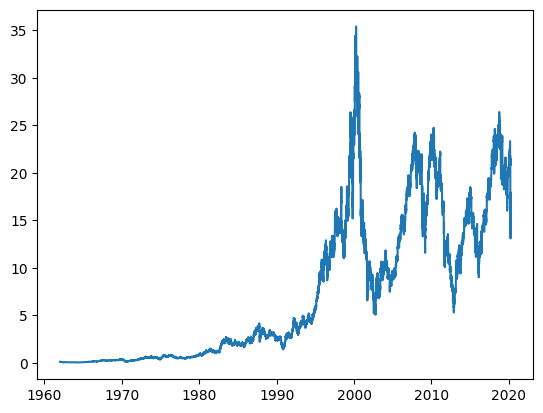

In [25]:
plt.plot(primero_GE.Date, primero_GE.Close)

In [26]:
primero_GE['reg_log'] =  np.log(primero_GE.Close.shift(-1) / primero_GE.Close)

In [27]:
primero_GE.head()

,Date,Open,High,Low,Close,Adj Close,Volume,reg_log
0,1962-01-02,0.131273,0.131273,0.124177,0.124177,0.006887,2480300,-0.010772
1,1962-01-03,0.124177,0.124177,0.121516,0.122846,0.006813,507300,-0.021899
2,1962-01-04,0.122846,0.126838,0.117968,0.120185,0.006666,845500,-0.022389
3,1962-01-05,0.119742,0.119742,0.117525,0.117525,0.006518,338200,0.014982
4,1962-01-08,0.117525,0.119299,0.115307,0.119299,0.006617,873700,0.014760


In [39]:
def volatilidad(df):
    try:
        df['reg_log']
        pass
    except KeyError:
        df['reg_log'] =  np.log(df.Close.shift(-1) / df.Close)
    return df.reg_log.std()
    
def crecimiento_continuo_promedio(df):
    try: 
        df['reg_log']
        pass
    except KeyError:
        df['reg_log'] =  np.log(df.Close.shift(-1) / df.Close)
    return df.reg_log.mean()
def ultimos_5_anios(df):
    fecha_corte_5_años = df.Date.iloc[-1] - pd.DateOffset(years=5)
    return df[df.Date > fecha_corte_5_años].copy()
    
    

In [30]:
tabla_simbolos = pd.read_csv('symbols_valid_meta.csv')
tabla_simbolos

,Nasdaq Traded,Symbol,Security Name,Listing Exchange,Market Category,ETF,Round Lot Size,Test Issue,Financial Status,CQS Symbol,NASDAQ Symbol,NextShares
0,Y,A,"Agilent Technologies, Inc. Common Stock",N,,N,100.0,N,NaN,A,A,N
1,Y,AA,Alcoa Corporation Common Stock,N,,N,100.0,N,NaN,AA,AA,N
2,Y,AAAU,Perth Mint Physical Gold ETF,P,,Y,100.0,N,NaN,AAAU,AAAU,N
3,Y,AACG,ATA Creativity Global - American Depositary Sh...,Q,G,N,100.0,N,N,NaN,AACG,N
4,Y,AADR,AdvisorShares Dorsey Wright ADR ETF,P,,Y,100.0,N,NaN,AADR,AADR,N
...,...,...,...,...,...,...,...,...,...,...,...,...
8044,Y,ZUO,"Zuora, Inc. Class A Common Stock",N,,N,100.0,N,NaN,ZUO,ZUO,N
8045,Y,ZVO,Zovio Inc. - Common Stock,Q,Q,N,100.0,N,N,NaN,ZVO,N
8046,Y,ZYME,Zymeworks Inc. Common Shares,N,,N,100.0,N,NaN,ZYME,ZYME,N
8047,Y,ZYNE,"Zynerba Pharmaceuticals, Inc. - Common Stock",Q,G,N,100.0,N,N,NaN,ZYNE,N


In [31]:
[simbolo for _,ruta, simbolo in csv_mas_grandes]
    

['HPQ', 'GE', 'DIS', 'ARNC', 'AA', 'IP', 'MO', 'BA', 'KO', 'MRO']

In [45]:
resumen = tabla_simbolos[tabla_simbolos.Symbol.isin(simbolo for _,ruta, simbolo in csv_mas_grandes)].copy()
resumen['volatilidad'] = np.nan
resumen['volatilidad_5'] = np.nan
resumen['crecimiento_continuo_promedio'] = np.nan
resumen['crecimiento_continuo_promedio_5'] = np.nan

In [46]:
for _, ruta, simbolo in csv_mas_grandes:
    historico = pd.read_csv(ruta)
    historico.Date = pd.to_datetime(historico.Date)
    ultimos_5 = ultimos_5_anios(historico)

    resumen.loc[resumen.Symbol == simbolo, 'crecimiento_continuo_promedio'] = crecimiento_continuo_promedio(historico)
    resumen.loc[resumen.Symbol == simbolo, 'volatilidad'] = volatilidad(historico)
    resumen.loc[resumen.Symbol == simbolo, 'crecimiento_continuo_promedio_5'] = crecimiento_continuo_promedio(ultimos_5)
    resumen.loc[resumen.Symbol == simbolo, 'volatilidad_5'] = volatilidad(ultimos_5)resumen.loc[resumen.Symbol == simbolo, 'crecimiento_continuo_promedio'] = crecimiento_continuo_promedio(historico)
    resumen.loc[resumen.Symbol == simbolo, 'volatilidad'] = volatilidad(historico)

    

In [47]:
resumen

,Nasdaq Traded,Symbol,Security Name,Listing Exchange,Market Category,ETF,Round Lot Size,Test Issue,Financial Status,CQS Symbol,NASDAQ Symbol,NextShares,volatilidad,volatilidad_5,crecimiento_continuo_promedio,crecimiento_continuo_promedio_5
1,Y,AA,Alcoa Corporation Common Stock,N,,N,100.0,N,NaN,AA,AA,N,0.021957,0.030199,-0.000003,-0.001288
445,Y,ARNC,Arconic Corporation Common Stock,N,,N,100.0,N,NaN,ARNC,ARNC,N,0.021616,0.028687,0.000052,-0.000641
604,Y,BA,Boeing Company (The) Common Stock,N,,N,100.0,N,NaN,BA,BA,N,0.020793,0.023742,0.000346,-0.000106
1801,Y,DIS,Walt Disney Company (The) Common Stock,N,,N,100.0,N,NaN,DIS,DIS,N,0.019872,0.015557,0.000473,-0.000088
2950,Y,GE,General Electric Company Common Stock,N,,N,100.0,N,NaN,GE,GE,N,0.016827,0.022272,0.000153,-0.000974
3407,Y,HPQ,HP Inc. Common Stock,N,,N,100.0,N,NaN,HPQ,HPQ,N,0.022637,0.021512,0.000326,0.000032
3790,Y,IP,International Paper Company Common Stock,N,,N,100.0,N,NaN,IP,IP,N,0.019203,0.018460,0.000084,-0.000473
4184,Y,KO,Coca-Cola Company (The) Common Stock,N,,N,100.0,N,NaN,KO,KO,N,0.014687,0.011417,0.000346,0.000028
4722,Y,MO,"Altria Group, Inc.",N,,N,100.0,N,NaN,MO,MO,N,0.019213,0.014823,0.000360,-0.000245
4772,Y,MRO,Marathon Oil Corporation Common Stock,N,,N,100.0,N,NaN,MRO,MRO,N,0.022662,0.036556,-0.000048,-0.001717
